Week 1

Lab Task 1

### Compute Summary Statistics
Let's load the dataset and compute the mean of $x$, mean of $y$, standard deviation of both, and the correlation between them for each of the 13 datasets.

In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/datasaurus.csv')

# Group by dataset and compute summary statistics
stats = df.groupby('dataset').agg(
    mean_x=('x', 'mean'),
    mean_y=('y', 'mean'),
    std_x=('x', 'std'),
    std_y=('y', 'std'),
    correlation=('x', lambda x: x.corr(df.loc[x.index, 'y']))
).reset_index()

display(stats)

,dataset,mean_x,mean_y,std_x,std_y,correlation
0,away,54.266100,47.834721,16.769825,26.939743,-0.064128
1,bullseye,54.268730,47.830823,16.769239,26.935727,-0.068586
2,circle,54.267320,47.837717,16.760013,26.930036,-0.068343
3,dino,54.263273,47.832253,16.765142,26.935403,-0.064472
4,dots,54.260303,47.839829,16.767735,26.930192,-0.060341
5,h_lines,54.261442,47.830252,16.765898,26.939876,-0.061715
6,high_lines,54.268805,47.835450,16.766704,26.939998,-0.068504
7,slant_down,54.267849,47.835896,16.766759,26.936105,-0.068980
8,slant_up,54.265882,47.831496,16.768853,26.938608,-0.068609
9,star,54.267341,47.839545,16.768959,26.930275,-0.062961


### What to Conclude if the Table Were All We Had

If this summary statistics table were all we had, we would conclude that all 13 datasets are virtually identical. They share almost exactly the same average values for $x$ (~54.26) and $y$ (~47.83), the same spread (standard deviation of $x$ ~16.77, and $y$ ~26.93), and the same weak negative correlation (~ -0.06). Without visualization, we would assume these datasets represent the same underlying phenomenon or distribution.

### Visualizing the 13 Datasets

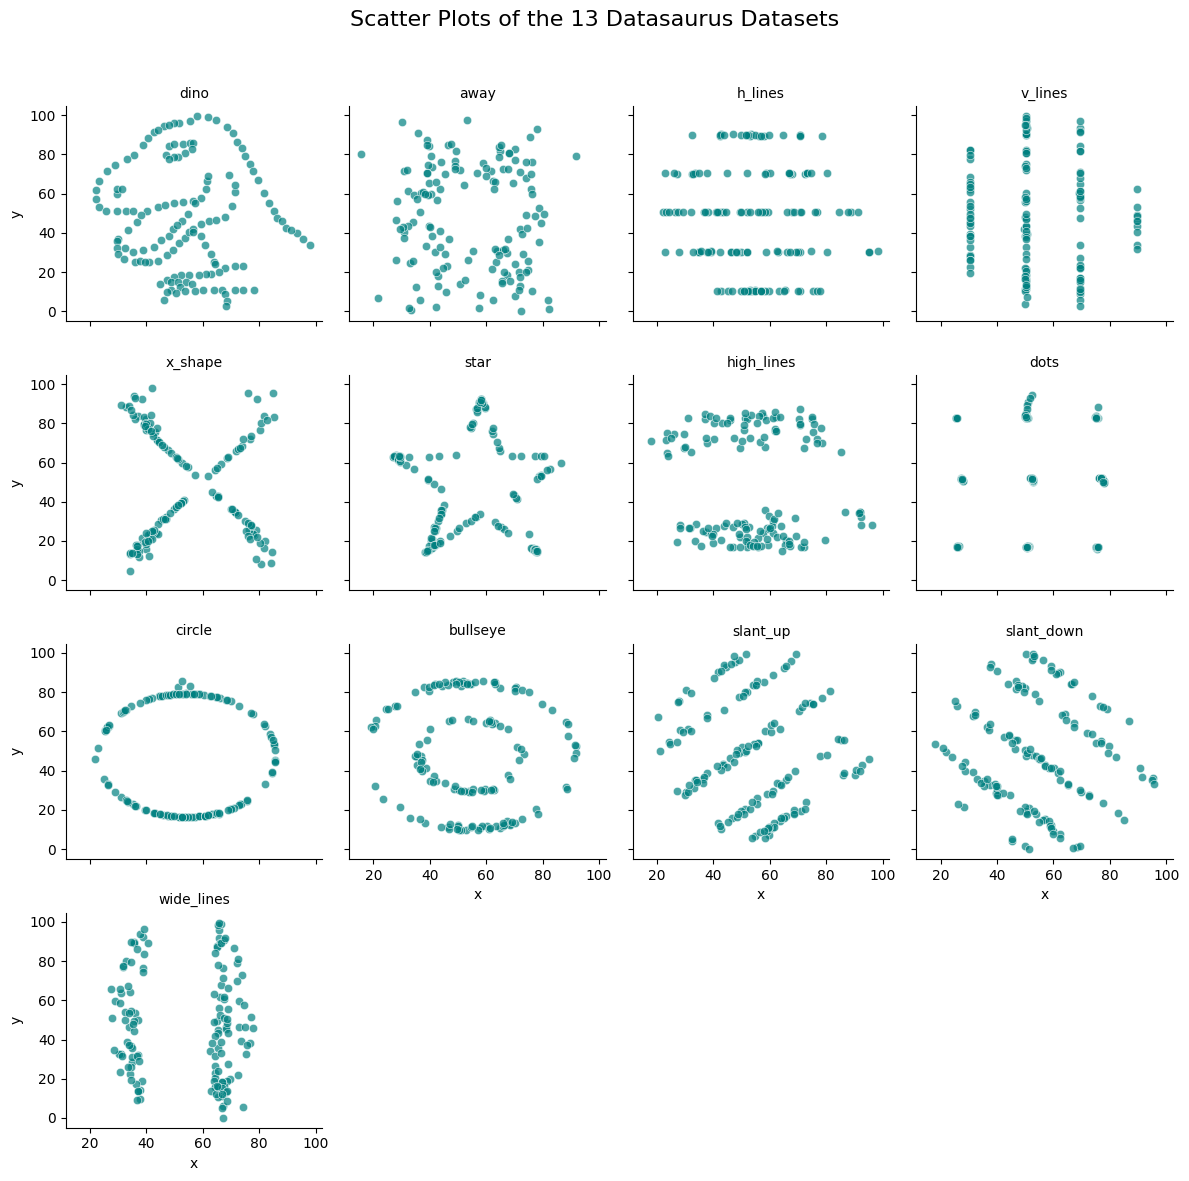

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting grid
g = sns.FacetGrid(df, col="dataset", col_wrap=4, height=3, sharex=True, sharey=True)
g.map(sns.scatterplot, "x", "y", alpha=0.7, color='teal')

# Adjust layout
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Scatter Plots of the 13 Datasaurus Datasets", fontsize=16)
plt.show()

### Conclusion and Discussion

**What we actually found:**
Upon plotting the data, we reveal wildly different distributions and structures! One of the datasets is shaped exactly like a Dinosaur (the famous "dino"), while others form circles, stars, horizontal lines, bulls-eyes, and various other geometric shapes. Despite having completely identical summary statistics down to several decimal places, their actual spatial distributions are entirely distinct.

**Does having 13 datasets and 142 points make summary statistics any more trustworthy?**
No, having more datasets and more data points (142 points per dataset compared to Anscombe's 11) does not make summary statistics any more trustworthy.

* **Why?** Summary statistics like mean, standard deviation, and linear correlation are simple aggregations that reduce a complex set of points into a few numbers. This reduction inherently discards structural pattern information. As the Datasaurus Dozen demonstrates, you can mathematically construct an infinite number of highly distinct datasets with a large number of points that share the exact same summary metrics. Therefore, visualization remains an indispensable step in data analysis, regardless of sample size.

# New section